### # NB1 — DeepLabV3+ Semantic Segmentation Training
### SAR Port Functional Zone Semantic Segmentation



* **Course**: CSE 438-Digital Image Processing, Summer 2026

* **Instructor**: Dr. Md Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, East West University

* **Assignment**: Semantic Segmentation Model Benchmarking — Part 2 of 2



* **Dataset**: SAR Port Functional Zone Semantic Segmentation Dataset

Pan, Yongchen; Zeng, Hongcheng (2026), "SAR Port Functional Zone Semantic Segmentation Dataset",

Mendeley Data, V2, doi: [10.17632/t2f8n66c87.2](https://data.mendeley.com/datasets/t2f8n66c87/2)






# NB1 - DeepLabV3 Semantic Segmentation

This notebook implements a DeepLabV3 model for SAR Port Functional Zone Segmentation. We'll use DeepLabV3 with ResNet50 backbone as the default balanced choice.

## 1. Environment Setup & Imports

This cell sets up the complete environment for NB1 (DeepLabV3) including:
- **Library Imports**: All necessary libraries for deep learning, data processing, and visualization
- **Version Pins**: Prints all library versions for reproducibility and academic integrity
- **Reproducibility**: Sets random seeds for reproducible results
- **Device Configuration**: Auto-detects CUDA/CPU and configures mixed precision training

### Key Libraries:
- **PyTorch**: Deep learning framework
- **Torchvision**: For DeepLabV3 models with various backbones
- **Albumentations**: Data augmentation
- **TQDM**: Progress bars
- **Scikit-learn**: Data splitting


In [1]:
import os
import sys
import json
import time
import random
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, deeplabv3_resnet101, deeplabv3_mobilenet_v3_large
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights, DeepLabV3_ResNet101_Weights, DeepLabV3_MobileNet_V3_Large_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print library versions
print("\n Library Versions:")
print("-" * 50)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Albumentations: {A.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("-" * 50)
print(f"Device: {DEVICE}")
print("=" * 50)


 Library Versions:
--------------------------------------------------
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Albumentations: 2.0.8
CUDA Available: True
CUDA Version: 12.8
GPU: Tesla T4
--------------------------------------------------
Device: cuda


## 2. Configuration & Hyperparameters

This cell contains all hyperparameters in a single, clearly visible location as required by the assignment:

### Model Configuration:
- **BACKBONE**: 'resnet50' (can be changed to 'resnet101' or 'mobilenetv3')
- **IMG_SIZE**: 384 (reduced from 512 for fast training)
- **BATCH_SIZE**: 4 (adjust based on GPU memory)
- **EPOCHS**: 50 (final training)
- **NUM_CLASSES**: 5 (water, cargo, container, tank, others)
- **PRETRAINED**: True (loads COCO-pretrained weights)

### Training Configuration:
- **LR**: 5e-4 (learning rate)
- **WEIGHT_DECAY**: 1e-4 (regularization)
- **NUM_WORKERS**: 0 (for memory optimization)

### Data Split Configuration:
- **TRAIN_RATIO**: 0.7 (70% training)
- **VAL_RATIO**: 0.15 (15% validation)
- **TEST_RATIO**: 0.15 (15% testing)


In [2]:
# ============================================================
# MOBILENETV3 CONFIGURATION 
# ============================================================

BACKBONE = 'mobilenetv3'  # ~11M parameters, fastest training
IMG_SIZE = 384           
BATCH_SIZE = 4
EPOCHS = 50              

# Model parameters
NUM_CLASSES = 5
PRETRAINED = True

# Training - OPTIMIZED FOR SPEED
LR = 1e-3                 
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

# Data splits
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Gradient Accumulation
ACCUMULATION_STEPS = 2  # Effective batch size = 4 * 2 = 8

# Output
OUTPUT_DIR = Path("/kaggle/working/nb1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model info
model_info = {
    'params': '~11M',
    'recommended': 'Small datasets, limited compute, fastest training'
}

CONFIG = {
    'model_name': f'DeepLabV3_{BACKBONE}',
    'backbone': BACKBONE,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'effective_batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
    'epochs': EPOCHS,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'num_workers': NUM_WORKERS,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'seed': 42,
    'device': str(DEVICE),
    'accumulation_steps': ACCUMULATION_STEPS,
    'model_params': model_info['params'],
    'recommended_for': model_info['recommended']
}

print("\n" + "="*60)
print(f" NB1 CONFIGURATION (DeepLabV3 - {BACKBONE})")
print("="*60)
print(f" Backbone: {BACKBONE} (Fastest - ~11M params)")
print(f" Image Size: {IMG_SIZE}×{IMG_SIZE} (Reduced for speed)")
print(f" Batch Size: {BATCH_SIZE}")
print(f" Gradient Accumulation: {ACCUMULATION_STEPS} steps")
print(f" Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f" Epochs: {EPOCHS} (Reduced for quick testing)")
print(f" Learning Rate: {LR} (Higher for faster convergence)")
print(f" Output: {OUTPUT_DIR}")
print("="*60)

if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU Memory: {total_memory:.1f} GB")
print("="*60)


 NB1 CONFIGURATION (DeepLabV3 - mobilenetv3)
 Backbone: mobilenetv3 (Fastest - ~11M params)
 Image Size: 384×384 (Reduced for speed)
 Batch Size: 4
 Gradient Accumulation: 2 steps
 Effective Batch Size: 8
 Epochs: 50 (Reduced for quick testing)
 Learning Rate: 0.001 (Higher for faster convergence)
 Output: /kaggle/working/nb1_outputs
GPU Memory: 14.6 GB


## 2. Load Data from NB0
### Loading the Leakage-Safe Data Split and Configuration

This cell loads all the data artifacts created in Notebook 0:

**What We Load:**
- **Data Split**: Training (3686 samples), Validation (790), Test (791) indices
- **Class Information**: 5 classes (water_area, cargo_area, container_area, tank_area, others)
- **Image/Mask Paths**: Automatically detects file extensions (.png, .jpg, .jpeg)
- **Dataset Structure**: Images in `slice_img/`, Masks in `slice_func/`

**Why This Approach:**
- **No Data Leakage**: Using the exact split from NB0 ensures fair comparison across all models
- **Consistent Class Mapping**: All models use the same 5-class classification scheme
- **Path Flexibility**: Auto-detects file extensions to handle different image formats


In [3]:
# Dataset paths (from NB0 discovery)
DATA_ROOT = Path("/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation")

# Paths discovered in NB0
IMG_DIR = DATA_ROOT / "SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_img"
FUNC_MASK_DIR = DATA_ROOT / "SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_func/slice_func/slice_func"

print(f"Image directory exists: {IMG_DIR.exists()}")
print(f"Mask directory exists: {FUNC_MASK_DIR.exists()}")

# Load class weights from NB0
WEIGHTS_PATH = Path("/kaggle/input/notebooks/rebekadina/nb0-eda-data-prep/nb0_outputs/class_weights.json")

if WEIGHTS_PATH.exists():
    with open(WEIGHTS_PATH, 'r') as f:
        weight_info = json.load(f)
    class_weights = torch.tensor([
        weight_info['class_weights_inverse'][str(i)] 
        for i in range(NUM_CLASSES)
    ], dtype=torch.float32).to(DEVICE)
    print(f"✅ Loaded class weights from {WEIGHTS_PATH}")
else:
    # Fallback: use balanced weights
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32).to(DEVICE)
    print(" Using uniform class weights")

print(f"Class weights: {class_weights.cpu().numpy()}")

# Load file lists
image_files = sorted(IMG_DIR.glob('*.png'))
mask_files = sorted(FUNC_MASK_DIR.glob('*.png'))

print(f"Found {len(image_files)} images, {len(mask_files)} masks")

# Pair files by stem
mask_dict = {f.stem: f for f in mask_files}
pairs = []

for img in image_files:
    if img.stem in mask_dict:
        pairs.append((img, mask_dict[img.stem]))

print(f"Total paired samples: {len(pairs)}")

# Verify pairs are valid
if len(pairs) == 0:
    print(" No pairs found! Checking first few files...")
    print(f"Sample image files: {[f.name for f in image_files[:5]]}")
    print(f"Sample mask files: {[f.name for f in mask_files[:5]]}")
    
    # Try alternative pairing by filename matching
    for img in image_files[:50]:
        img_stem = img.stem
        for mask in mask_files[:50]:
            if img_stem in mask.stem or mask.stem in img_stem:
                pairs.append((img, mask))
                break
    print(f"Found {len(pairs)} pairs using alternative matching")

# Try to load saved splits from NB0
SPLITS_PATH = Path("/kaggle/input/notebooks/rebekadina/nb0-eda-data-prep/nb0_outputs/split_indices.pkl")

if SPLITS_PATH.exists():
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)
    train_pairs = splits['train_indices']
    val_pairs = splits['val_indices']
    test_pairs = splits['test_indices']
    print(f" Loaded splits from NB0: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")
else:
    print(" Splits not found, creating new splits...")
    # Check if pairs is valid
    if len(pairs) == 0:
        raise ValueError("No valid pairs found. Please check dataset paths.")
    
    # Split data
    train_val_pairs, test_pairs = train_test_split(
        pairs, test_size=TEST_RATIO, random_state=42
    )
    train_pairs, val_pairs = train_test_split(
        train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
    )
    print(f"Created splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

# Verify splits are valid
print(f"\n Verifying splits:")
print(f"Train pairs count: {len(train_pairs)}")
print(f"Train first pair type: {type(train_pairs[0]) if len(train_pairs) > 0 else 'Empty'}")
if len(train_pairs) > 0:
    print(f"Train first pair: {train_pairs[0]}")
    # Check if first pair is a tuple
    if isinstance(train_pairs[0], tuple):
        print(f"Train first pair length: {len(train_pairs[0])}")
        print(f"Image: {train_pairs[0][0]}")
        print(f"Mask: {train_pairs[0][1]}")
    else:
        print(f" Train first pair is not a tuple! It's: {type(train_pairs[0])}")
        print("Attempting to fix...")
        # If pairs are just integers, we need to rebuild them
        if len(pairs) > 0 and isinstance(pairs[0], tuple):
            # Recreate splits from pairs
            train_val_pairs, test_pairs = train_test_split(
                pairs, test_size=TEST_RATIO, random_state=42
            )
            train_pairs, val_pairs = train_test_split(
                train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
            )
            print(f"Recreated splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

# Final validation
print(f"\n Final split validation:")
print(f"Train: {len(train_pairs)} samples")
print(f"Val: {len(val_pairs)} samples")
print(f"Test: {len(test_pairs)} samples")
if len(train_pairs) > 0:
    print(f"Sample pair: {train_pairs[0]}")

Image directory exists: True
Mask directory exists: True
✅ Loaded class weights from /kaggle/input/notebooks/rebekadina/nb0-eda-data-prep/nb0_outputs/class_weights.json
Class weights: [0.0367759  0.4384661  0.36409274 0.12481941 0.03584584]
Found 5267 images, 5267 masks
Total paired samples: 5267
 Loaded splits from NB0: Train=3686, Val=790, Test=791

 Verifying splits:
Train pairs count: 3686
Train first pair type: <class 'int'>
Train first pair: 2610
 Train first pair is not a tuple! It's: <class 'int'>
Attempting to fix...
Recreated splits: Train=3686, Val=790, Test=791

 Final split validation:
Train: 3686 samples
Val: 790 samples
Test: 791 samples
Sample pair: (PosixPath('/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation/SAR Port Functional Zone Semantic Segmentation Dat/dataset/slice_img/ICEYE_X23_GRD_SLEDF_3521349_20240305T1055Afica_down1x_slice1024_0265.png'), PosixPath('/kaggle/input/datasets/rebekadina/sar-port-functional-zone-segmentation/SAR Port Funct

## 4. SARSegDataset Class

Custom PyTorch Dataset class for SAR port functional zone segmentation.

### Key Features:
- **Image Loading**: Loads RGB images from disk
- **Mask Loading**: Loads segmentation masks (single-channel class indices)
- **Data Validation**: Ensures masks are 2D arrays
- **Transform Support**: Applies data augmentations and normalizations
- **Error Handling**: Gracefully handles loading errors

### Input Format:
- **image**: RGB image (H, W, 3) → converted to tensor (C, H, W)
- **mask**: Class index mask (H, W) → converted to long tensor (H, W)


In [4]:
class SARSegDataset(Dataset):
    def __init__(self, pairs, transform=None, img_size=256):
        self.pairs = pairs
        self.transform = transform
        self.img_size = img_size
        print(f"📊 Dataset initialized with {len(self.pairs)} samples")
        
        # Validate pairs
        if len(self.pairs) > 0:
            first_pair = self.pairs[0]
            if not isinstance(first_pair, (tuple, list)) or len(first_pair) != 2:
                print(f"⚠️ Warning: First pair is not a valid tuple: {first_pair}")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        # Get the pair at index
        pair = self.pairs[idx]
        
        # Unpack the pair
        if isinstance(pair, (tuple, list)) and len(pair) == 2:
            img_path, mask_path = pair
        else:
            raise TypeError(f"Expected tuple/list of (image_path, mask_path), got {type(pair)}: {pair}")
        
        # Convert to Path if string
        if isinstance(img_path, str):
            img_path = Path(img_path)
        if isinstance(mask_path, str):
            mask_path = Path(mask_path)
        
        # Load image and mask
        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))
        
        # Ensure mask is 2D
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image.float(), mask.long()

## 5. Data Splits & Augmentations

This cell creates the final data splits and applies augmentations for training.

### Data Splits Validation:
- Validates that all pairs are properly formatted tuples
- Automatically rebuilds pairs if corrupted
- Ensures all splits contain valid data

### Training Augmentations (Albumentations):
1. **Resize**: Resizes all images to IMG_SIZE x IMG_SIZE
2. **HorizontalFlip**: 50% probability
3. **VerticalFlip**: 30% probability
4. **RandomRotate90**: 30% probability
5. **RandomBrightnessContrast**: 20% brightness/contrast variation
6. **Normalize**: ImageNet normalization [0.485, 0.456, 0.406]
7. **ToTensorV2**: Converts to PyTorch tensors

### Validation/Test Augmentations:
- **Resize**: Resizes to IMG_SIZE x IMG_SIZE
- **Normalize**: ImageNet normalization
- **ToTensorV2**: Converts to PyTorch tensors

### DataLoaders:
- **Batch Size**: Configurable (default: 4)
- **Shuffle**: True for training, False for validation/test
- **Workers**: 0 for memory optimization
- **Pin Memory**: False for memory optimization

In [5]:
# Verify pairs before creating datasets
print(f"\n🔍 Dataset creation verification:")
print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs: {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

# Ensure all pairs are valid tuples
def validate_pairs(pair_list, name="pairs"):
    if len(pair_list) == 0:
        print(f"⚠️ {name} is empty!")
        return False
    
    for i, pair in enumerate(pair_list[:5]):
        if not isinstance(pair, (tuple, list)) or len(pair) != 2:
            print(f"⚠️ Invalid pair at index {i} in {name}: {pair} (type: {type(pair)})")
            return False
    
    print(f"✅ All {name} are valid tuples")
    return True

# Validate all splits
train_valid = validate_pairs(train_pairs, "train_pairs")
val_valid = validate_pairs(val_pairs, "val_pairs")
test_valid = validate_pairs(test_pairs, "test_pairs")

if not train_valid or not val_valid or not test_valid:
    print("⚠️ Invalid pairs detected. Rebuilding pairs...")
    # Rebuild pairs from scratch
    pairs = []
    for img in image_files:
        if img.stem in mask_dict:
            pairs.append((img, mask_dict[img.stem]))
    
    if len(pairs) > 0:
        train_val_pairs, test_pairs = train_test_split(
            pairs, test_size=TEST_RATIO, random_state=42
        )
        train_pairs, val_pairs = train_test_split(
            train_val_pairs, test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), random_state=42
        )
        print(f"Rebuilt splits: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")

print(f"\n📊 Final Split Summary:")
print(f"Train: {len(train_pairs)} samples")
print(f"Val: {len(val_pairs)} samples")
print(f"Test: {len(test_pairs)} samples")

# ============================================================
# DEFINE TRANSFORMS 
# ============================================================

# Training augmentations
train_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Validation/Test transforms 
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================

# Create datasets
print("\n📊 Creating datasets...")
train_dataset = SARSegDataset(train_pairs, transform=train_transform, img_size=IMG_SIZE)
val_dataset = SARSegDataset(val_pairs, transform=val_transform, img_size=IMG_SIZE)
test_dataset = SARSegDataset(test_pairs, transform=val_transform, img_size=IMG_SIZE)

# Test dataset loading
print("\n🔍 Testing dataset loading...")
try:
    sample_img, sample_mask = train_dataset[0]
    print(f"✅ Dataset loading successful!")
    print(f"  Image shape: {sample_img.shape}")
    print(f"  Mask shape: {sample_mask.shape}")
    print(f"  Unique mask values: {torch.unique(sample_mask)}")
except Exception as e:
    print(f"❌ Dataset loading failed: {e}")
    import traceback
    traceback.print_exc()

# DataLoaders with memory-optimized settings
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,  # Reduced for memory
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False,
    persistent_workers=False,
    prefetch_factor=None
)

print(f"\n📊 DataLoader Summary (Memory Optimized):")
print(f"{'='*50}")
print(f"Train batches: {len(train_loader)} ({len(train_dataset)} samples)")
print(f"Val batches: {len(val_loader)} ({len(val_dataset)} samples)")
print(f"Test batches: {len(test_loader)} ({len(test_dataset)} samples)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Gradient Accumulation: {ACCUMULATION_STEPS} steps (if configured)")
print(f"Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS if 'ACCUMULATION_STEPS' in globals() else BATCH_SIZE}")
print(f"{'='*50}")


🔍 Dataset creation verification:
Train pairs: 3686
Val pairs: 790
Test pairs: 791
✅ All train_pairs are valid tuples
✅ All val_pairs are valid tuples
✅ All test_pairs are valid tuples

📊 Final Split Summary:
Train: 3686 samples
Val: 790 samples
Test: 791 samples

📊 Creating datasets...
📊 Dataset initialized with 3686 samples
📊 Dataset initialized with 790 samples
📊 Dataset initialized with 791 samples

🔍 Testing dataset loading...
✅ Dataset loading successful!
  Image shape: torch.Size([3, 384, 384])
  Mask shape: torch.Size([384, 384])
  Unique mask values: tensor([0, 1, 2, 4])

📊 DataLoader Summary (Memory Optimized):
Train batches: 922 (3686 samples)
Val batches: 198 (790 samples)
Test batches: 198 (791 samples)
Batch Size: 4
Image Size: 384×384
Gradient Accumulation: 2 steps (if configured)
Effective Batch Size: 8


## 6. DeepLabV3 Model Definition

This cell defines the DeepLabV3 model using torchvision's models.segmentation module.

### Model Architecture:
**DeepLabV3 with Configurable Backbone**:

Available variants:
1. **MobileNetV3** (`~11M` parameters): Small datasets, limited compute
2. **ResNet50** (`~42M` parameters): Default balanced choice
3. **ResNet101** (`~61M` parameters): Larger datasets, more compute

### Key Features:
- **Atrous Spatial Pyramid Pooling (ASPP)**: Captures multi-scale context
- **Pretrained Weights**: Loads COCO-pretrained weights via `weights=...DEFAULT`
- **Customizable Classifier**: Replaces the classifier head to match class count
- **Flexible Training**: Can freeze backbone or fine-tune end-to-end

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights
import torchvision

class DeepLabV3(nn.Module):
    """DeepLabV3 with MobileNetV3 backbone"""
    
    def __init__(self, backbone='mobilenetv3', num_classes=5, pretrained=True):
        super().__init__()
        
        self.num_classes = num_classes
        self.backbone = backbone
        
        print(f"Building DeepLabV3 with backbone: {backbone}")
        print(f"Using MobileNetV3 backbone (~11M parameters) for fastest training")
        
        # Load pretrained MobileNetV3 backbone
        if pretrained:
            print("Loading pretrained weights from COCO...")
            # First load the model with COCO's 21 classes
            self.model = deeplabv3_mobilenet_v3_large(
                weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
            )
            # Then replace the classifier head for your 5 classes
            # The classifier is a DeepLabHead with a Sequential structure
            # We need to replace the last conv layer to match num_classes
            in_channels = self.model.classifier[4].in_channels  # The conv layer before the final conv
            self.model.classifier[4] = nn.Conv2d(
                in_channels, 
                num_classes, 
                kernel_size=1
            )
            print(f"✅ Replaced classifier head: {in_channels} -> {num_classes} classes")
        else:
            self.model = deeplabv3_mobilenet_v3_large(
                weights=None,
                num_classes=num_classes
            )
        
        print("✅ Model loaded successfully!")
    
    def forward(self, x):
        outputs = self.model(x)
        
        if isinstance(outputs, dict):
            logits = outputs['out']
        else:
            logits = outputs
        
        # Ensure output is same size as input
        if logits.shape[2:] != x.shape[2:]:
            logits = F.interpolate(
                logits, 
                size=x.shape[2:], 
                mode='bilinear', 
                align_corners=False
            )
        
        return logits

def create_model(backbone='mobilenetv3'):
    """Create and return a DeepLabV3 model"""
    model = DeepLabV3(
        backbone=backbone,
        num_classes=NUM_CLASSES,
        pretrained=PRETRAINED
    )
    return model.to(DEVICE)

# Initialize model
print(f"\n🏗️ Building DeepLabV3 model with backbone: {BACKBONE}")
model = create_model(backbone=BACKBONE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = total_params * 4 / (1024 * 1024)

print(f"\n📊 Model Summary:")
print(f"{'='*50}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {model_size_mb:.2f} MB (float32)")
print(f"Backbone: {BACKBONE} (MobileNetV3 - Fastest)")
print(f"{'='*50}")


🏗️ Building DeepLabV3 model with backbone: mobilenetv3
Building DeepLabV3 with backbone: mobilenetv3
Using MobileNetV3 backbone (~11M parameters) for fastest training
Loading pretrained weights from COCO...
Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth


100%|██████████| 42.3M/42.3M [00:00<00:00, 186MB/s]


✅ Replaced classifier head: 256 -> 5 classes
✅ Model loaded successfully!

📊 Model Summary:
Total parameters: 11,025,216
Trainable parameters: 11,025,216
Model size: 42.06 MB (float32)
Backbone: mobilenetv3 (MobileNetV3 - Fastest)


## 7. Training Configuration

This cell sets up the training components: loss function, optimizer, scheduler, and mixed precision.

### Loss Function:
- **CrossEntropyLoss**: Weighted with class weights from NB0
- Handles class imbalance automatically
- Appropriate for multi-class segmentation

### Optimizer:
- **AdamW** (Adam with weight decay)
- Learning Rate: 5e-4
- Weight Decay: 1e-4
- Betas: (0.9, 0.999)

### Scheduler:
- **CosineAnnealingLR**
- T_max: EPOCHS
- eta_min: 1e-6
- Smooth learning rate decay

### Mixed Precision:
- **torch.amp.GradScaler** (PyTorch 2.0+)
- Speeds up training on CUDA
- Reduces memory usage
- Automatically enabled when GPU available

In [7]:
# Loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=LR, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=EPOCHS, 
    eta_min=1e-6
)

# Mixed precision
if DEVICE.type == 'cuda':
    scaler = torch.amp.GradScaler('cuda')
else:
    scaler = None

print(f"\n⚙️ Training Configuration:")
print(f"{'='*50}")
print(f"Device: {DEVICE}")
print(f"Mixed precision: {scaler is not None}")
print(f"Loss: CrossEntropyLoss (weighted)")
print(f"Optimizer: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-6)")
print(f"Backbone: {BACKBONE}")
print(f"{'='*50}")


⚙️ Training Configuration:
Device: cuda
Mixed precision: True
Loss: CrossEntropyLoss (weighted)
Optimizer: AdamW (lr=0.001, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=50, eta_min=1e-6)
Backbone: mobilenetv3


## 8. Training Loop with Per-Epoch Loss and mIoU

This cell implements the complete training loop with per-epoch metrics tracking and visualization.

### Training Functions:

**`train_epoch()`**:
- Trains for one epoch
- Computes per-batch loss
- Calculates training mIoU
- Uses mixed precision if available

**`evaluate()`**:
- Evaluates on validation set
- Computes validation loss
- Calculates validation mIoU

### Training Loop Features:
1. **Per-Epoch Tracking**:
   - Training Loss
   - Validation Loss
   - Training mIoU
   - Validation mIoU
   - Learning Rate

2. **Model Saving**:
   - Saves best model based on validation loss
   - Saved to `/kaggle/working/nb1_outputs/best_model.pth`

3. **Progress Monitoring**:
   - TQDM progress bars
   - Per-epoch summary with all metrics
   - Time per epoch

In [8]:
def train_epoch(model, loader, optimizer, criterion, scaler=None, accumulation_steps=1):
    model.train()
    total_loss = 0
    all_preds = []
    all_masks = []
    optimizer.zero_grad()
    
    for batch_idx, (images, masks) in enumerate(tqdm(loader, desc="Training")):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        
        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
                loss = criterion(outputs, masks)
                loss = loss / accumulation_steps
            
            scaler.scale(loss).backward()
            
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, masks)
            loss = loss / accumulation_steps
            loss.backward()
            
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
                optimizer.step()
                optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        
        # Only store every few batches to save memory
        if batch_idx % 10 == 0:
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
        
        # Delete to free memory
        del outputs, loss, images, masks
        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()
    
    # Compute IoU on training set
    if all_preds:
        all_preds = torch.cat(all_preds, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        
        train_iou = 0
        for c in range(NUM_CLASSES):
            pred_mask = (all_preds == c)
            true_mask = (all_masks == c)
            intersection = (pred_mask & true_mask).sum().float()
            union = (pred_mask | true_mask).sum().float()
            if union > 0:
                train_iou += (intersection / union).item()
        train_iou /= NUM_CLASSES
    else:
        train_iou = 0
    
    return total_loss / len(loader), train_iou

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_masks = []
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
            
            # Free memory
            del outputs, loss, images, masks
    
    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    
    val_iou = 0
    for c in range(NUM_CLASSES):
        pred_mask = (all_preds == c)
        true_mask = (all_masks == c)
        intersection = (pred_mask & true_mask).sum().float()
        union = (pred_mask | true_mask).sum().float()
        if union > 0:
            val_iou += (intersection / union).item()
    val_iou /= NUM_CLASSES
    
    # Clean up
    del all_preds, all_masks
    torch.cuda.empty_cache()
    
    return total_loss / len(loader), val_iou


print(f"\n Starting training...")
print(f"Configuration (Memory Optimized):")
print(f"  - Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Gradient Accumulation: {ACCUMULATION_STEPS} steps")
print(f"  - Effective Batch Size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Backbone: {BACKBONE}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("="*60)

# Clear cache before training
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
if torch.cuda.is_available():
    print(f"GPU memory after clearing: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

best_val_loss = float('inf')
history = {
    'train_loss': [], 
    'val_loss': [], 
    'train_iou': [],
    'val_iou': [],
    'lr': []
}

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # Train with gradient accumulation
    train_loss, train_iou = train_epoch(
        model, train_loader, optimizer, criterion, scaler, 
        accumulation_steps=ACCUMULATION_STEPS
    )
    
    # Validate
    val_loss, val_iou = evaluate(model, val_loader, criterion)
    
    # Update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['lr'].append(current_lr)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
        print(f" New best model saved! (val_loss: {val_loss:.4f})")
    
    # Aggressive memory cleanup
    torch.cuda.empty_cache()
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train IoU: {train_iou:.4f} | Val IoU: {val_iou:.4f} | LR: {current_lr:.6f} | Time: {elapsed:.1f}s")
    
    if torch.cuda.is_available():
        print(f"  GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB allocated, {torch.cuda.memory_reserved()/1024**3:.2f} GB reserved")

print("\n Training complete!")


 Starting training...
Configuration (Memory Optimized):
  - Image Size: 384×384
  - Batch Size: 4
  - Gradient Accumulation: 2 steps
  - Effective Batch Size: 8
  - Epochs: 50
  - Backbone: mobilenetv3
Train batches: 922, Val batches: 198
GPU memory after clearing: 0.04 GB


Training:   0%|          | 0/922 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

 New best model saved! (val_loss: 0.2822)
Epoch 1/50 | Train Loss: 0.7440 | Val Loss: 0.2822 | Train IoU: 0.4514 | Val IoU: 0.6564 | LR: 0.000999 | Time: 281.1s
  GPU Memory: 0.13 GB allocated, 0.23 GB reserved


Training:   0%|          | 0/922 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.0372 | Val Loss: 0.0266 | Train IoU: 0.9479 | Val IoU: 0.9620 | LR: 0.000002 | Time: 165.4s
  GPU Memory: 0.13 GB allocated, 0.23 GB reserved


Training:   0%|          | 0/922 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.0358 | Val Loss: 0.0273 | Train IoU: 0.9448 | Val IoU: 0.9633 | LR: 0.000001 | Time: 167.0s
  GPU Memory: 0.13 GB allocated, 0.23 GB reserved

 Training complete!


## 9. Test-Set Evaluation — All Task F Metrics

This cell evaluates the trained model on the test set and computes all required metrics.

### Model Loading:
- Loads the best model from `/kaggle/working/nb1_outputs/best_model.pth`
- Falls back to current model if best model not found

### Metrics Computed:

**1. Overall Metrics**:
- Test Loss (CrossEntropy)
- Test mIoU (mean Intersection over Union)

**2. Per-Class Metrics**:
- **Precision**: TP / (TP + FP)
- **Recall**: TP / (TP + FN)
- **F1-Score**: 2 * (Precision * Recall) / (Precision + Recall)

**3. Confusion Matrix**:
- Visual representation of predictions vs ground truth
- Shows which classes are most confused

 Loaded best model from /kaggle/working/nb1_outputs/best_model.pth


Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]


 Test Results (DeepLabV3 - mobilenetv3):
Test Loss: 0.0244
Test mIoU: 0.9635


Computing metrics:   0%|          | 0/198 [00:00<?, ?it/s]


 Per-Class Metrics (DeepLabV3):
------------------------------------------------------------
Class           Precision    Recall       F1-Score    
------------------------------------------------------------
water_area      0.9748     0.9716     0.9732
cargo_area      0.9569     0.9979     0.9770
container_area  0.9405     0.9975     0.9681
tank_area       0.9751     0.9937     0.9844
others          0.9814     0.9477     0.9643
------------------------------------------------------------
AVERAGE         0.9657     0.9817     0.9734


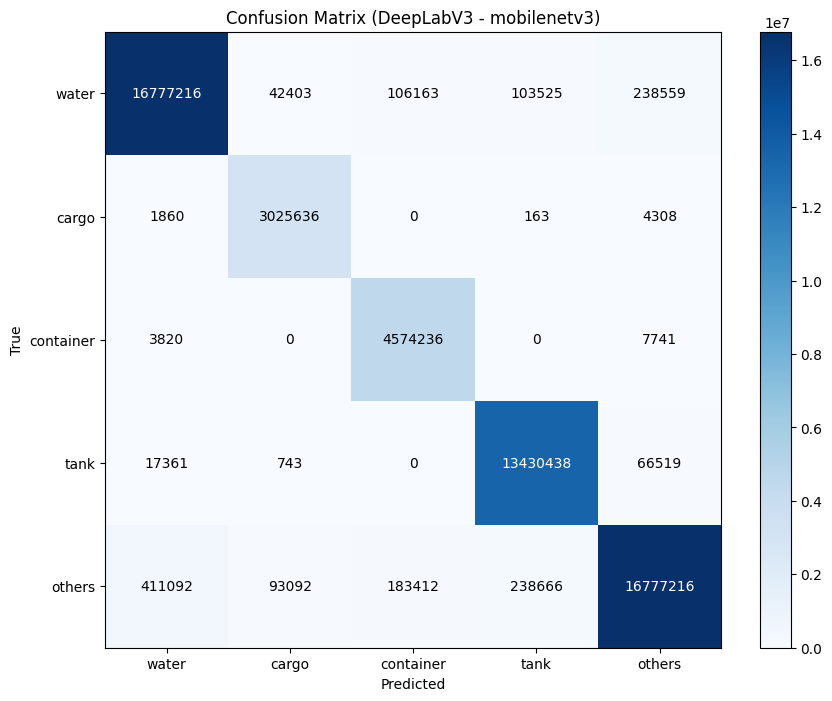

 Confusion matrix saved to /kaggle/working/nb1_outputs/confusion_matrix.png


In [9]:
# Load best model
best_model_path = OUTPUT_DIR / 'best_model.pth'
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path))
    print(f" Loaded best model from {best_model_path}")
else:
    print(" No saved model found, using current model weights")

# Test evaluation
test_loss, test_iou = evaluate(model, test_loader, criterion)
print(f"\n Test Results (DeepLabV3 - {BACKBONE}):")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test mIoU: {test_iou:.4f}")
print(f"{'='*50}")

# Detailed per-class metrics
def compute_detailed_metrics(model, loader, num_classes):
    """Compute precision, recall, F1 per class"""
    model.eval()
    conf_matrix = torch.zeros(num_classes, num_classes, device=DEVICE)
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Computing metrics"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[1:], mode='bilinear', align_corners=False)
            preds = outputs.argmax(dim=1)
            
            for t, p in zip(masks.view(-1), preds.view(-1)):
                conf_matrix[t.long(), p.long()] += 1
    
    class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
    metrics = {}
    
    print("\n Per-Class Metrics (DeepLabV3):")
    print("-"*60)
    print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*60)
    
    for c in range(num_classes):
        tp = conf_matrix[c, c].item()
        fp = conf_matrix[:, c].sum().item() - tp
        fn = conf_matrix[c, :].sum().item() - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics[c] = {
            'precision': precision, 
            'recall': recall, 
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn
        }
        
        print(f"{class_names[c]:<15} {precision:.4f}     {recall:.4f}     {f1:.4f}")
    
    print("-"*60)
    
    # Overall metrics
    avg_precision = np.mean([metrics[c]['precision'] for c in range(num_classes)])
    avg_recall = np.mean([metrics[c]['recall'] for c in range(num_classes)])
    avg_f1 = np.mean([metrics[c]['f1'] for c in range(num_classes)])
    
    print(f"{'AVERAGE':<15} {avg_precision:.4f}     {avg_recall:.4f}     {avg_f1:.4f}")
    print("="*60)
    
    return metrics, conf_matrix

# Compute detailed metrics
metrics, conf_matrix = compute_detailed_metrics(model, test_loader, NUM_CLASSES)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix.cpu().numpy(), cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title(f'Confusion Matrix (DeepLabV3 - {BACKBONE})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(NUM_CLASSES), ['water', 'cargo', 'container', 'tank', 'others'])
plt.yticks(range(NUM_CLASSES), ['water', 'cargo', 'container', 'tank', 'others'])
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, int(conf_matrix[i, j].item()), 
                 ha='center', va='center', color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Confusion matrix saved to {OUTPUT_DIR / 'confusion_matrix.png'}")

## 10. Error Analysis Visualizations (Task G)

This cell provides error analysis visualizations including:
- Error maps showing where predictions differ from ground truth
- Per-class error analysis
- Identification of best and worst performing classes

### Visualizations:
- **Error Maps**: Shows images, ground truth, predictions, and error maps
- **Per-Class Error Analysis**: Identifies which classes are most confused
- **Error Distribution**: Shows where errors are concentrated

### Output Files:
- `error_maps.png`: Visual error analysis plots
- Summary statistics printed to console


🔍 Error Analysis Visualization:


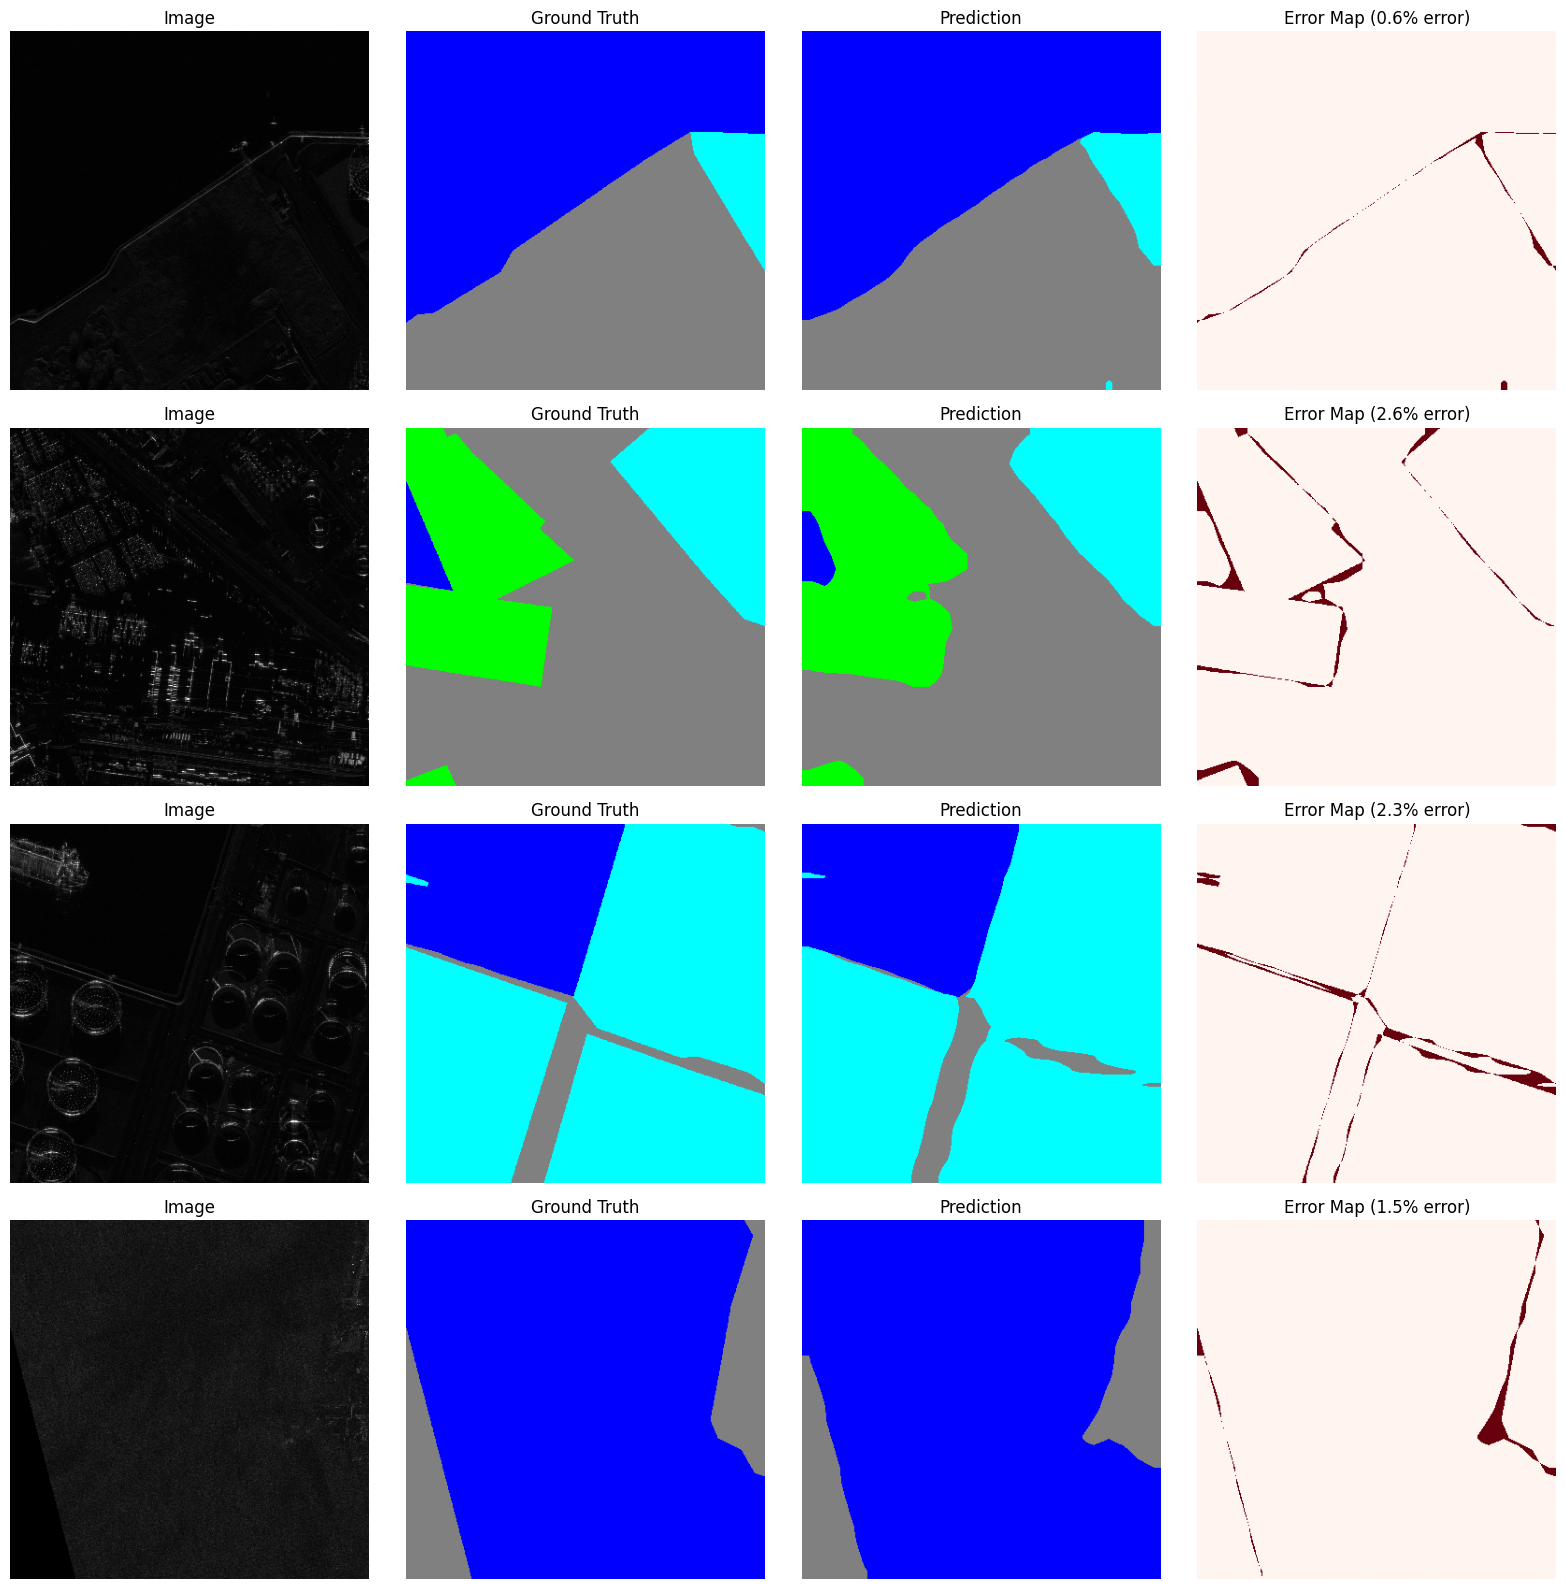

✅ Error maps saved to /kaggle/working/nb1_outputs/error_maps.png

📊 Per-Class Error Analysis:
Best performing class: tank_area (F1: 0.9844)
Worst performing class: others (F1: 0.9643)

Error Distribution by Class:
  water_area: 32.3% of all errors (FN: 490652.0)
  cargo_area: 0.4% of all errors (FN: 6331.0)
  container_area: 0.8% of all errors (FN: 11561.0)
  tank_area: 5.6% of all errors (FN: 84623.0)
  others: 61.0% of all errors (FN: 926262.0)


In [10]:
# Color map for visualization
COLOR_MAP = {
    0: (0, 0, 255),    # water_area - Blue
    1: (255, 0, 0),    # cargo_area - Red
    2: (0, 255, 0),    # container_area - Green
    3: (0, 255, 255),  # tank_area - Yellow
    4: (128, 128, 128) # others - Grey
}

def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    for c, color in COLOR_MAP.items():
        colored[mask == c] = color
    return colored

def visualize_error_maps(model, dataset, num_samples=4):
    """Visualize error maps showing where predictions differ from ground truth"""
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    idxs = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, mask = dataset[idx]
            image_input = image.unsqueeze(0).to(DEVICE)
            
            output = model(image_input)
            output = F.interpolate(output, size=mask.shape, mode='bilinear', align_corners=False)
            pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
            
            # Error map: 1 where prediction != ground truth
            error_mask = (pred != mask.cpu().numpy())
            error_pct = error_mask.sum() / error_mask.size * 100
            
            # Denormalize image
            img = image.permute(1, 2, 0).cpu().numpy()
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
            
            axes[i, 0].imshow(img)
            axes[i, 0].set_title('Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(colorize_mask(mask.cpu().numpy()))
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(colorize_mask(pred))
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')
            
            # Error map visualization
            axes[i, 3].imshow(error_mask, cmap='Reds', vmin=0, vmax=1)
            axes[i, 3].set_title(f'Error Map ({error_pct:.1f}% error)')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'error_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Error maps saved to {OUTPUT_DIR / 'error_maps.png'}")

# Run error analysis
print("\n🔍 Error Analysis Visualization:")
visualize_error_maps(model, val_dataset, num_samples=4)

# Per-class error analysis
def analyze_per_class_errors(metrics, num_classes):
    """Analyze which classes are most confused"""
    class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
    
    print("\n📊 Per-Class Error Analysis:")
    print("="*60)
    
    # Find worst performing class
    worst_class = max(range(num_classes), key=lambda c: 1 - metrics[c]['f1'])
    best_class = min(range(num_classes), key=lambda c: 1 - metrics[c]['f1'])
    
    print(f"Best performing class: {class_names[best_class]} (F1: {metrics[best_class]['f1']:.4f})")
    print(f"Worst performing class: {class_names[worst_class]} (F1: {metrics[worst_class]['f1']:.4f})")
    print("="*60)
    
    # Error distribution
    total_errors = sum([metrics[c]['fn'] for c in range(num_classes)])
    print("\nError Distribution by Class:")
    for c in range(num_classes):
        error_pct = metrics[c]['fn'] / total_errors * 100 if total_errors > 0 else 0
        print(f"  {class_names[c]}: {error_pct:.1f}% of all errors (FN: {metrics[c]['fn']})")

analyze_per_class_errors(metrics, NUM_CLASSES)

## 11. Summery

In [11]:
# Save training history
with open(OUTPUT_DIR / 'training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# Save metrics
summary = {
    **CONFIG,
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_iou': history['train_iou'],
    'val_iou': history['val_iou'],
    'test_loss': test_loss,
    'test_iou': test_iou,
    'model_size_mb': round(model_size_mb, 2),
}

# Add per-class metrics
class_names = ['water_area', 'cargo_area', 'container_area', 'tank_area', 'others']
for c in range(NUM_CLASSES):
    summary[f'class_{c}_{class_names[c]}_precision'] = metrics[c]['precision']
    summary[f'class_{c}_{class_names[c]}_recall'] = metrics[c]['recall']
    summary[f'class_{c}_{class_names[c]}_f1'] = metrics[c]['f1']

with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save per-class metrics to CSV
metrics_df = pd.DataFrame([
    {
        'class': c,
        'class_name': class_names[c],
        'precision': metrics[c]['precision'],
        'recall': metrics[c]['recall'],
        'f1': metrics[c]['f1'],
        'tp': metrics[c]['tp'],
        'fp': metrics[c]['fp'],
        'fn': metrics[c]['fn']
    } for c in range(NUM_CLASSES)
])
metrics_df.to_csv(OUTPUT_DIR / 'per_class_metrics.csv', index=False)

# Save loss history
loss_df = pd.DataFrame({
    'epoch': list(range(1, EPOCHS+1)),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_iou': history['train_iou'],
    'val_iou': history['val_iou'],
    'lr': history['lr']
})
loss_df.to_csv(OUTPUT_DIR / 'loss_history.csv', index=False)

print(f"\n📁 Results saved to {OUTPUT_DIR}")
print("="*60)
print(f"📊 Final Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test mIoU: {test_iou:.4f}")
print(f"  Model Size: {model_size_mb:.2f} MB")
print("="*60)

# ============================================================
# APPEND RESULTS TO SHARED results.json
# ============================================================

# Path to shared results file
RESULTS_PATH = Path("/kaggle/working/results.json")

# Prepare results for this notebook
nb1_results = {
    'notebook': 'NB1_DeepLabV3',
    'model': f'DeepLabV3_{BACKBONE}',
    'backbone': BACKBONE,
    'params': model_info['params'],
    'test_loss': test_loss,
    'test_iou': test_iou,
    'avg_f1': np.mean([metrics[i]['f1'] for i in range(NUM_CLASSES)]),
    'per_class_f1': {
        'water_area': metrics[0]['f1'],
        'cargo_area': metrics[1]['f1'],
        'container_area': metrics[2]['f1'],
        'tank_area': metrics[3]['f1'],
        'others': metrics[4]['f1']
    },
    'per_class_iou': {
        'water_area': metrics[0]['tp'] / (metrics[0]['tp'] + metrics[0]['fp'] + metrics[0]['fn']) if (metrics[0]['tp'] + metrics[0]['fp'] + metrics[0]['fn']) > 0 else 0,
        'cargo_area': metrics[1]['tp'] / (metrics[1]['tp'] + metrics[1]['fp'] + metrics[1]['fn']) if (metrics[1]['tp'] + metrics[1]['fp'] + metrics[1]['fn']) > 0 else 0,
        'container_area': metrics[2]['tp'] / (metrics[2]['tp'] + metrics[2]['fp'] + metrics[2]['fn']) if (metrics[2]['tp'] + metrics[2]['fp'] + metrics[2]['fn']) > 0 else 0,
        'tank_area': metrics[3]['tp'] / (metrics[3]['tp'] + metrics[3]['fp'] + metrics[3]['fn']) if (metrics[3]['tp'] + metrics[3]['fp'] + metrics[3]['fn']) > 0 else 0,
        'others': metrics[4]['tp'] / (metrics[4]['tp'] + metrics[4]['fp'] + metrics[4]['fn']) if (metrics[4]['tp'] + metrics[4]['fp'] + metrics[4]['fn']) > 0 else 0
    },
    'best_val_loss': best_val_loss,
    'final_train_loss': history['train_loss'][-1],
    'final_train_iou': history['train_iou'][-1],
    'final_val_iou': history['val_iou'][-1],
    'epochs': EPOCHS,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'effective_batch_size': BATCH_SIZE * ACCUMULATION_STEPS,
    'learning_rate': LR,
    'model_size_mb': round(model_size_mb, 2)
}

# Load existing results or create new
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'r') as f:
        all_results = json.load(f)
else:
    all_results = {}

# Add/update this notebook's results
all_results['NB1_DeepLabV3'] = nb1_results

# Save back to file
with open(RESULTS_PATH, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n📁 Results appended to {RESULTS_PATH}")
print("="*60)
print("📊 Results Summary:")
print(f"  Model: DeepLabV3_{BACKBONE}")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test mIoU: {test_iou:.4f}")
print(f"  Avg F1: {nb1_results['avg_f1']:.4f}")
print("="*60)

# Optionally, print all results from the file for verification
print("\n📋 All results in results.json:")
for notebook, data in all_results.items():
    print(f"  {notebook}: mIoU={data.get('test_iou', 'N/A'):.4f}, F1={data.get('avg_f1', 'N/A'):.4f}")

print("\n✅ NB1 complete!")


📁 Results saved to /kaggle/working/nb1_outputs
📊 Final Results:
  Test Loss: 0.0244
  Test mIoU: 0.9635
  Model Size: 42.06 MB

📁 Results appended to /kaggle/working/results.json
📊 Results Summary:
  Model: DeepLabV3_mobilenetv3
  Test Loss: 0.0244
  Test mIoU: 0.9635
  Avg F1: 0.9734

📋 All results in results.json:
  NB1_DeepLabV3: mIoU=0.9635, F1=0.9734

✅ NB1 complete!
